# Module 06 — S-band GCOV Polarimetric Exploration

**File used:** `NISAR_S2_PR_GCOV_025_141_A_015_3700_DHNA_A_20260717T231346_20260717T231423_P00500_M_F_I_001.h5`

**Product / band:** GCOV (L2, geocoded covariance), S-band, track 141 / frame 015, ascending, processed by ISRO (baseline P00500) — the same file used in Module 05.

**Why this file:** per `docs/data_inventory.md` and confirmed again below, this is the one GCOV sample that carries an **off-diagonal covariance term (HHHV)** in addition to the two diagonal power terms — which is what makes the polarimetric step in this notebook possible at all. It lives under `science/SSAR/...` rather than `science/LSAR/...` (auto-detected by `nisar_tools.io`, not hardcoded).

**Region:** same as Modules 03/05 — northeastern India, Brahmaputra valley / Meghalaya-Bhutan foothill terrain.

## Scope & Caveats

This notebook computes the **HH-HV complex correlation coefficient**, the simplest polarimetric product that requires an off-diagonal covariance term. It is **not** a full polarimetric decomposition (e.g. Cloude-Pottier entropy/alpha, Freeman-Durden three-component) — those require quad-pol data (HH, HV, VH, VV), which neither this file nor any other sample in this repo contains (this is a dual-pol, H-transmit-only product). No ground truth or reference land-cover data has been used to interpret the result below — any scattering-mechanism language is general SAR polarimetry theory, not a validated claim about this scene.

Geographic language is strictly technical (terrain/elevation/backscatter).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

## Why Module 06 can do this and Module 03 couldn't

This is stated explicitly here, not just implied — we open both GCOV sample files and print their available covariance terms side by side:

In [2]:
GCOV_S_PATH = SAMPLE_DATA_DIR / "NISAR_S2_PR_GCOV_025_141_A_015_3700_DHNA_A_20260717T231346_20260717T231423_P00500_M_F_I_001.h5"
GCOV_L_PATH = SAMPLE_DATA_DIR / "NISAR_L2_PR_GCOV_026_091_D_075_4005_DHDH_A_20260726T123348_20260726T123423_P05023_N_F_J_001.h5"

gcov_s = open_product(GCOV_S_PATH)

with open_product(GCOV_L_PATH) as gcov_l_peek:
    terms_l = gcov_l_peek.list_covariance_terms("A")
terms_s = gcov_s.list_covariance_terms("A")

print(f"Module 03 file (L-band, science/{'LSAR'}/...): covariance terms = {terms_l}")
print(f"Module 06 file (S-band, science/{gcov_s.band_group}/...): covariance terms = {terms_s}")
print()
print(f"  HHHV (off-diagonal) present in Module 03's file: {'HHHV' in terms_l}")
print(f"  HHHV (off-diagonal) present in Module 06's file: {'HHHV' in terms_s}")
print()
print("The HH-HV correlation coefficient below is rho = HHHV / sqrt(HHHH * HVHV) --")
print("it needs HHHV in the numerator, so it is only computable for the file on the right.")

Module 03 file (L-band, science/LSAR/...): covariance terms = ['HHHH', 'HVHV']
Module 06 file (S-band, science/SSAR/...): covariance terms = ['HHHH', 'HVHV', 'HHHV']

  HHHV (off-diagonal) present in Module 03's file: False
  HHHV (off-diagonal) present in Module 06's file: True

The HH-HV correlation coefficient below is rho = HHHV / sqrt(HHHH * HVHV) --
it needs HHHV in the numerator, so it is only computable for the file on the right.


## Theory recap

See **Module 00, Section 7** for the full explanation, including a synthetic (non-real-data) demonstration of the estimator-bias effect this module finds below.

## The HH-HV correlation coefficient

`nisar_tools.preprocess.hh_hv_correlation(hhhh, hvhv, hhhv)` computes:

rho = HHHV / sqrt(HHHH * HVHV)

`|rho|` (in [0, 1]) indicates how correlated the co-pol (HH) and cross-pol (HV) returns are: higher values are generally associated with more surface-like (single/double-bounce dominated) scattering, lower values with more depolarizing, volume-like scattering (e.g. dense vegetation canopy). `arg(rho)` is their relative phase. This is a real dual-pol polarimetric product -- but it is **not** a substitute for full quad-pol decomposition, which would additionally need VH and VV.

We reuse the same 20 km x 20 km shared window from Module 05 for continuity (it contains a visually distinctive river meander).

In [3]:
WINDOW_X = (360_000, 380_000)
WINDOW_Y = (2_910_000, 2_930_000)

coords = gcov_s.coordinates("A")
row_slice, col_slice = prep.coordinate_window(coords["x"], coords["y"], *WINDOW_X, *WINDOW_Y)

hhhh = gcov_s.get_covariance_dataset("HHHH", "A")[row_slice, col_slice]
hvhv = gcov_s.get_covariance_dataset("HVHV", "A")[row_slice, col_slice]
hhhv = gcov_s.get_covariance_dataset("HHHV", "A")[row_slice, col_slice]
print("Window shape:", hhhh.shape, " HHHV dtype:", hhhv.dtype)

extent = [coords["x"][col_slice][0], coords["x"][col_slice][-1], coords["y"][row_slice][-1], coords["y"][row_slice][0]]

valid_mask = np.isfinite(hhhh) & np.isfinite(hvhv) & np.isfinite(hhhv) & (hhhh > 0) & (hvhv > 0)
print(f"Valid pixel fraction: {valid_mask.mean():.1%}")

rho = prep.hh_hv_correlation(hhhh, hvhv, hhhv)
rho_mag = np.where(valid_mask, np.abs(rho), np.nan)
rho_phase = np.where(valid_mask, np.angle(rho), np.nan)

print(f"|rho|: min={np.nanmin(rho_mag):.3f}, median={np.nanmedian(rho_mag):.3f}, max={np.nanmax(rho_mag):.3f}")

Window shape: (2000, 2000)  HHHV dtype: complex64
Valid pixel fraction: 100.0%


|rho|: min=0.000, median=0.532, max=0.994


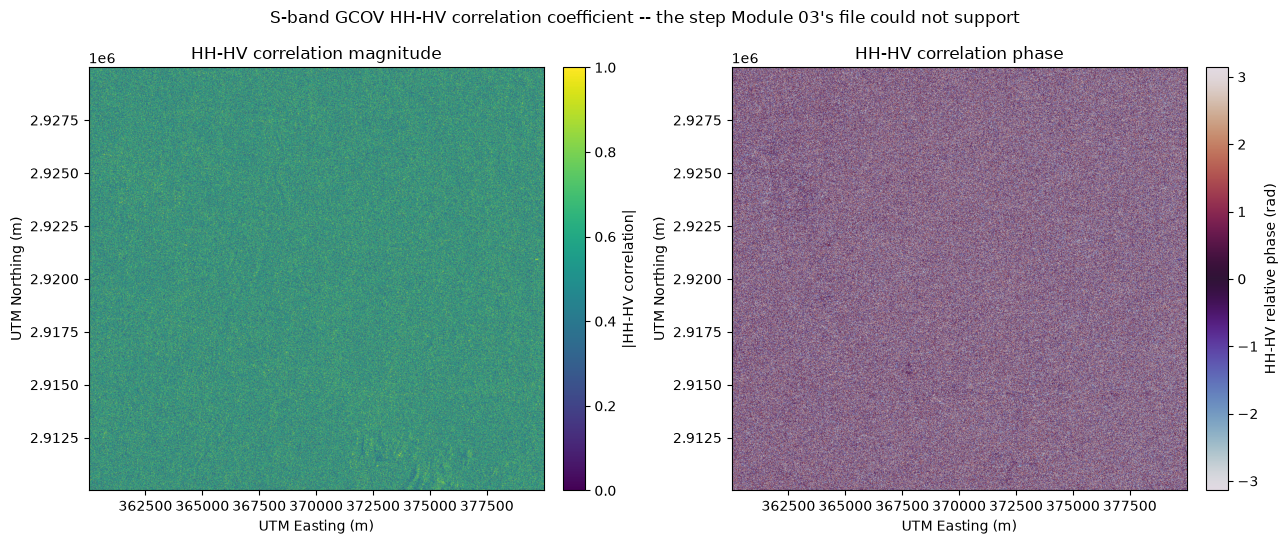

In [4]:
fig, axes = viz.new_figure(ncols=2)
viz.imshow_masked(
    axes[0], rho_mag, valid_mask=valid_mask, cmap="viridis", vmin=0, vmax=1, extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="|HH-HV correlation|",
    title="HH-HV correlation magnitude",
)
viz.imshow_phase(
    axes[1], rho_phase, valid_mask=valid_mask, extent=extent,
    xlabel="UTM Easting (m)", ylabel="UTM Northing (m)", colorbar_label="HH-HV relative phase (rad)",
    title="HH-HV correlation phase",
)
fig.suptitle("S-band GCOV HH-HV correlation coefficient -- the step Module 03's file could not support")
fig.tight_layout()
plt.show()

## Checking the result: is |rho| = 0.52 real, or estimator bias?

The magnitude map above doesn't obviously show the river meander that stood out so clearly in Module 05's backscatter-power imagery -- worth checking rather than assuming. A sample correlation coefficient like this one, computed pixel-by-pixel, is a known-biased estimator: when the *true* underlying correlation is low, a limited-sample estimate is still pulled upward, and that bias shrinks as more independent samples are averaged in. We can test for this directly: average (multilook) the HHHH/HVHV/HHHV terms themselves *before* forming the ratio (not the other way around -- averaging the ratio of noisy per-pixel estimates does not fix this), across a few different look counts, and see whether the mean magnitude is stable (real signal) or keeps dropping (bias).

In [5]:
for looks in (1, 4, 8, 16):
    if looks == 1:
        h, v, x = hhhh, hvhv, hhhv
    else:
        h = prep.multilook(hhhh, looks, looks)
        v = prep.multilook(hvhv, looks, looks)
        x = prep.multilook(hhhv.real, looks, looks) + 1j * prep.multilook(hhhv.imag, looks, looks)
    mag_ml = np.abs(prep.hh_hv_correlation(h, v, x))
    print(f"{looks:2d}x{looks:<2d} multilook ({looks*looks:3d} extra looks): "
          f"mean |rho| = {np.nanmean(mag_ml):.3f}, std = {np.nanstd(mag_ml):.3f}, shape = {mag_ml.shape}")

 1x1  multilook (  1 extra looks): mean |rho| = 0.520, std = 0.208, shape = (2000, 2000)
 4x4  multilook ( 16 extra looks): mean |rho| = 0.192, std = 0.108, shape = (500, 500)


 8x8  multilook ( 64 extra looks): mean |rho| = 0.116, std = 0.084, shape = (250, 250)
16x16 multilook (256 extra looks): mean |rho| = 0.078, std = 0.078, shape = (125, 125)


The mean magnitude drops sharply with more averaging (roughly 0.52 -> 0.19 -> 0.12 -> 0.08 across 1x1 to 16x16), rather than stabilizing. That pattern is the signature of **estimator bias dominating a genuinely low true correlation**, not a real, moderately-strong HH-HV correlation being revealed with less noise. Put plainly: most of what the native-resolution map above shows is statistical noise inflating the apparent correlation, not real physical structure -- and this is exactly why the river meander doesn't show up here the way it did in Module 05's backscatter-power comparison. This is a genuinely useful negative result: it demonstrates the computation and the estimator-bias check, without overselling what a single, unaveraged dual-pol correlation product can actually tell us about this scene.

In [6]:
gcov_s.close()

## What real-world deployment would additionally require

- Quad-pol data (HH, HV, VH, VV) for an actual full polarimetric decomposition (Cloude-Pottier entropy/alpha/anisotropy, Freeman-Durden, etc.) -- the correlation coefficient computed here is a genuine but limited dual-pol polarimetric product, not a substitute.
- A validated reference land-cover map to check whether high/low correlation regions actually correspond to the surface-like/volume-like scattering interpretation offered above.
- Multilooking/speckle filtering before computing per-pixel correlation estimates, since coherence-like quantities (including this correlation coefficient) are statistically biased and noisy at 1 look.
- Radiometric terrain correction, given this scene's elevation relief, before attributing any spatial pattern in the correlation map to land cover rather than terrain geometry.